In [ ]:
! pip install torchdiffeq

In [ ]:
%matplotlib inline

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from mpl_toolkits.mplot3d import Axes3D
from torchdiffeq import odeint_adjoint as odeint  #Neural ODE с adjoint-методом

# 2. НАСТРОЙКИ ЭКСПЕРИМЕНТА

In [ ]:
batch_size = 64        # сколько кусочков траектории берём за один раз
batch_time = 20        # длина временного окна внутри батча(20 точек во времени)
data_size = 2000       # сколько точек по времени в истинной траектории
niters = 2500          # число итераций обучения
test_freq = 200        # как часто считать полную ошибку и рисовать графики
lr = 1e-3              # learning rate для Adam

#выбор устройства: GPU если он есть иначе CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

#принудительно считать на CPU
# device = torch.device("cpu")

print(f"Device: {device}")


Device: cpu


# 3. ПАРАМЕТРЫ 3D-СИСТЕМЫ

Мы задаём не плоское движение $(x_1, x_2)$, а пространственное движение $(x, y, z)$.

## Система уравнений

$$
\frac{dx}{dt} = -\alpha (r^2 - R^2)x - \omega y + \kappa z
$$

$$
\frac{dy}{dt} = -\alpha (r^2 - R^2)y + \omega x
$$

$$
\frac{dz}{dt} = -\beta z + \eta x
$$

где

$$
r^2 = x^2 + y^2
$$

## Смысл системы

1. Переменные $x$ и $y$ описывают вращение вокруг оси $z$.
2. Член $-\alpha (r^2 - R^2)$ стабилизирует радиус траектории и не даёт ей "улетать".
3. Переменная $z$ связана с $x$, поэтому движение становится пространственным, а не плоским.

## Таблица параметров системы

| Параметр | Значение | Что он физически делает | Простая аналогия |
|---|---:|---|---|
| $\alpha$ | 2.0 | Сила возврата к целевому радиусу | Как пружина, которая тянет точку обратно к окружности радиусом $R = 1.0$ |
| $\omega$ | 2.5 | Угловая скорость вращения в плоскости $xy$ | Скорость, с которой точка крутится вокруг оси $z$ (как скорость вращения карусели) |
| $\beta$ | 0.8 | Затухание (трение) по оси $z$ | Сила, которая постепенно «гасит» движение вверх-вниз |
| $\eta$ | 0.7 | Связь из $x$ в $z$ | Как верёвка: когда $x$ меняется — это тянет $z$ за собой |
| $\kappa$ | 0.2 | Слабая обратная связь из $z$ в $x$ | Слабая верёвка в обратную сторону: $z$ немного влияет на $x$ |
| $R$ | 1.0 | Целевой радиус вращения | Радиус окружности, к которой система стремится |

In [ ]:
alpha = 2.0   # сила возврата к радиусу R
omega = 2.5   # угловая скорость вращения в плоскости (x, y)
beta = 0.8    # затухание по координате z
eta = 0.7     # связь x -> z
kappa = 0.2   # слабая обратная связь z -> x
R = 1.0       # целевой радиус вращения

# 4. НАЧАЛЬНОЕ СОСТОЯНИЕ И СЕТКА ВРЕМЕНИ

In [ ]:
true_y0 = torch.tensor([[1.2, 0.0, 0.8]], dtype=torch.float32).to(device)
# true_y0 имеет размер (1, 3):
# 1  -> одна траектория
# 3  -> три координаты: x, y, z

t = torch.linspace(0.0, 30.0, data_size).to(device)
#это временная сетка: от 0 до 30 сек, раздел на 2000 точек

# 5. ИСТИННАЯ ПРАВАЯ ЧАСТЬ СИСТЕМЫ

In [ ]:
class SpatialLambda(nn.Module):
    """
    3D-динамика, по которой мы генерируем обучающие данные
    Именно ее потом будет пытаться аппроксимировать Neural ODE
    """
    def forward(self, t, y):
        # y имеет форму (..., 3)
        # Последняя размерность = 3 координаты состояния: x, y, z

        x = y[..., 0]                      # берем первую координату
        y_coord = y[..., 1]                # берем вторую координату
        z = y[..., 2]                      # берем третью координату

        r2 = x**2 + y_coord**2             # квадрат расстояния до оси z в плоскости (x, y)

        dx = -alpha * (r2 - R**2) * x - omega * y_coord + kappa * z
        # -alpha*(r2 - R^2)*x  -> стабилизирует радиус
        # -omega*y             -> вращение в плоскости
        # +kappa*z             -> добавляет влияние z на x

        dy = -alpha * (r2 - R**2) * y_coord + omega * x
        # -alpha*(r2 - R^2)*y  -> стабилизация радиуса
        # +omega*x             -> вращение в плоскости

        dz = -beta * z + eta * x
        # -beta*z  -> затухание по оси z
        # +eta*x   -> связь с x, за счет чего возникает пространственная траектория

        return torch.stack([dx, dy, dz], dim=-1)
        # Собираем три производные обратно в вектор:
        # [dx/dt, dy/dt, dz/dt]


Если смотреть только на плоскость $xy$, то это квадрат радиуса точки относительно центра.

- если $r^2 > R^2$, точка слишком далеко;
- если $r^2 < R^2$, точка слишком близко;
- если $r^2 = R^2$, точка находится на целевой окружности.

# 6. ГЕНЕРАЦИЯ ТРАЕКТОРИИ

In [ ]:
with torch.no_grad():
    true_y = odeint(SpatialLambda(), true_y0, t, method='dopri5')
# true_y имеет размер (T, 1, 3), где:
# T = число точек времени
# 1 = одна траектория
# 3 = три координаты (x, y, z)

# 7. ФУНКЦИЯ ВЫБОРКИ БАТЧА

In [ ]:
def get_batch():
    """
    Берем случайные временные индексы s и строим батч коротких отрезков траектории.

    """
    s = torch.from_numpy(
        np.random.choice(
            np.arange(data_size - batch_time, dtype=np.int64),
            batch_size,
            replace=False
        )
    )

    batch_y0 = true_y[s]   #стартовые состояния для каждого окна
    #размер: (batch_size, 1, 3)

    batch_t = t[:batch_time]
    # одни и те же относительные моменты времени внутри окна
    # берём первые 20 точек временной сетки
    # размер: (batch_time,)

    batch_y = torch.stack([true_y[s + i] for i in range(batch_time)], dim=0)
    # собираем траектории на этих окнах
    # размер: (batch_time, batch_size, 1, 3)

    return batch_y0.to(device), batch_t.to(device), batch_y.to(device)


In [ ]:
def makedirs(dirname):
    if not os.path.exists(dirname):
        os.makedirs(dirname)

makedirs("png_3d")

#ВИЗУАЛИЗАЦИЯ

In [ ]:
def visualize(true_y, pred_y, odefunc, itr, z_slice=0.0):
    """
    Рисуем:
    1) графики x(t), y(t), z(t),
    2) 3D-траекторию,
    3) проекцию на плоскость (x, y),
    4) срез изученного векторного поля при фиксированном z = z_slice.
    """

    fig = plt.figure(figsize=(16, 10), facecolor='white')

    #координаты во времени
    ax_traj = fig.add_subplot(221, frameon=False)
    ax_traj.cla()
    ax_traj.set_title("Координаты во времени")
    ax_traj.set_xlabel("t")
    ax_traj.set_ylabel("x, y, z")

    t_np = t.cpu().numpy()

    true_np = true_y.cpu().numpy()[:, 0, :]
    pred_np = pred_y.cpu().numpy()[:, 0, :]

    ax_traj.plot(t_np, true_np[:, 0], 'g-', label='x true')
    ax_traj.plot(t_np, true_np[:, 1], 'b-', label='y true')
    ax_traj.plot(t_np, true_np[:, 2], 'r-', label='z true')

    ax_traj.plot(t_np, pred_np[:, 0], 'g--', label='x pred')
    ax_traj.plot(t_np, pred_np[:, 1], 'b--', label='y pred')
    ax_traj.plot(t_np, pred_np[:, 2], 'r--', label='z pred')

    ax_traj.legend(loc='upper right')
    ax_traj.grid(True, alpha=0.3)

    #3Д траектория
    ax_3d = fig.add_subplot(222, projection='3d')
    ax_3d.cla()
    ax_3d.set_title("Пространственная траектория")
    ax_3d.set_xlabel("x")
    ax_3d.set_ylabel("y")
    ax_3d.set_zlabel("z")

    ax_3d.plot(true_np[:, 0], true_np[:, 1], true_np[:, 2], 'g-', label='Истина')
    ax_3d.plot(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], 'b--', label='Прогноз')
    ax_3d.legend()

    #проекция на плоскость xy
    ax_phase = fig.add_subplot(223, frameon=False)
    ax_phase.cla()
    ax_phase.set_title("Проекция фазовой траектории на плоскость (x, y)")
    ax_phase.set_xlabel("x")
    ax_phase.set_ylabel("y")

    ax_phase.plot(true_np[:, 0], true_np[:, 1], 'g-', label='Истина')
    ax_phase.plot(pred_np[:, 0], pred_np[:, 1], 'b--', label='Прогноз')
    ax_phase.legend()
    ax_phase.grid(True, alpha=0.3)

    #векторное поле на срезе z = const
    ax_vec = fig.add_subplot(224, frameon=False)
    ax_vec.cla()
    ax_vec.set_title(f"Срез изученного поля при z = {z_slice}")
    ax_vec.set_xlabel("x")
    ax_vec.set_ylabel("y")

    y_grid, x_grid = np.mgrid[-1.5:1.5:20j, -1.5:1.5:20j]
    z_grid = np.ones_like(x_grid) * z_slice

    xyz_grid = np.stack([x_grid, y_grid, z_grid], axis=-1).reshape(-1, 3)

    with torch.no_grad():
        field = odefunc(
            0,
            torch.tensor(xyz_grid, dtype=torch.float32).to(device)
        ).cpu().numpy()

    u = field[:, 0].reshape(x_grid.shape)
    v = field[:, 1].reshape(y_grid.shape)

    mag = np.sqrt(u**2 + v**2) + 1e-8
    u = u / mag
    v = v / mag

    ax_vec.streamplot(x_grid, y_grid, u, v, color="black", density=1.0)
    ax_vec.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.savefig(f"png_3d/{itr:04d}.png")
    plt.show()


In [ ]:
#КЛАСС ДЛЯ СГЛАЖЕННОГО ЛОГИРОВАНИЯ
class RunningAverageMeter(object):
    """
    Хранит экспоненциально сглаженное среднее
    только для красивого логирования.
    """
    def __init__(self, momentum=0.99):
        self.momentum = momentum
        self.reset()

    def reset(self):
        self.val = None
        self.avg = 0

    def update(self, val):
        if self.val is None:
            self.avg = val
        else:
            self.avg = self.avg * self.momentum + val * (1 - self.momentum)
        self.val = val

# 11. НЕЙРОННАЯ ПРАВАЯ ЧАСТЬ ДЛЯ 3D-NEURAL ODE


In [ ]:
class ODEFunc3D(nn.Module):
    """
    Это уже не истинная система, а нейросетевая аппроксимация правой части.
    Она получает текущее состояние (x, y, z) и возвращает
    предсказание производных (dx/dt, dy/dt, dz/dt).
    """

    def __init__(self):
        super(ODEFunc3D, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),   # вход: 3 координаты -> 64 скрытых признака
            nn.Tanh(),          # нелинейность
            nn.Linear(64, 64),  # второй скрытый слой
            nn.Tanh(),          # нелинейность
            nn.Linear(64, 32),  # третий скрытый слой
            nn.Tanh(),          # нелинейность
            nn.Linear(32, 3),   # выход: 3 производные
        )

        # Инициализация весов
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.1)
                nn.init.constant_(m.bias, val=0.0)

    def forward(self, t, y):
        return self.net(y)
        # На входе текущее состояние y,
        # на выходе сеть возвращает оценку dy/dt


# 12. СОЗДАНИЕ МОДЕЛИ И ОПТИМИЗАТОРА


In [ ]:
func = ODEFunc3D().to(device)              # создаем нейросетевую правую часть
optimizer = optim.Adam(func.parameters(), lr=lr)  # оптимизатор Adam

time_meter = RunningAverageMeter(0.97)     # сглаженное время итерации
loss_meter = RunningAverageMeter(0.97)     # сглаженная ошибка

best_loss = np.inf                         # лучшая полная ошибка
loss_arr = np.zeros((2, niters))           # массив для кривой обучения

end = time.time()                          # отметка времени начала


# 13. ОБУЧЕНИЕ


In [ ]:
for itr in range(1, niters + 1):

    optimizer.zero_grad()
    # Обнуляем старые градиенты перед новым backward()

    batch_y0, batch_t, batch_y = get_batch()
    # batch_y0 - стартовые состояния в батче
    # batch_t  - локальная временная сетка окна
    # batch_y  - истинные траектории на этом окне

    pred_y = odeint(func, batch_y0, batch_t, method='dopri5')
    # Интегрируем нейросетевую правую часть func
    # Получаем предсказанную траекторию на окне

    loss = torch.mean(torch.abs(pred_y - batch_y))
    # Используем MAE (среднюю абсолютную ошибку)
    # Это полностью соответствует духу твоего исходного ноутбука

    loss_arr[0, itr - 1] = itr
    loss_arr[1, itr - 1] = loss.item()
    # Сохраняем номер итерации и значение ошибки для графика обучения

    loss.backward()
    # Считаем градиенты по параметрам сети

    optimizer.step()
    # Обновляем веса нейросети

    time_meter.update(time.time() - end)
    loss_meter.update(loss.item())

    # Каждые test_freq шагов смотрим полную траекторию, а не только батч
    if itr % test_freq == 0 or itr == 1:
        with torch.no_grad():
            pred_full = odeint(func, true_y0, t, method='dopri5')
            total_loss = torch.mean(torch.abs(pred_full - true_y)).item()

        print(
            f"Iter {itr:04d} | "
            f"Batch Loss {loss.item():.6f} | "
            f"Full Loss {total_loss:.6f} | "
            f"Time Avg {time_meter.avg:.4f}"
        )

        if total_loss < best_loss:
            best_loss = total_loss
            torch.save(func.state_dict(), "best_model_3d.pth")
            print(f"Best model saved at iter {itr:04d} with Full Loss {total_loss:.6f}")

            with torch.no_grad():
                visualize(true_y, pred_full, func, itr)

    end = time.time()

# 14. ГРАФИК ОБУЧЕНИЯ


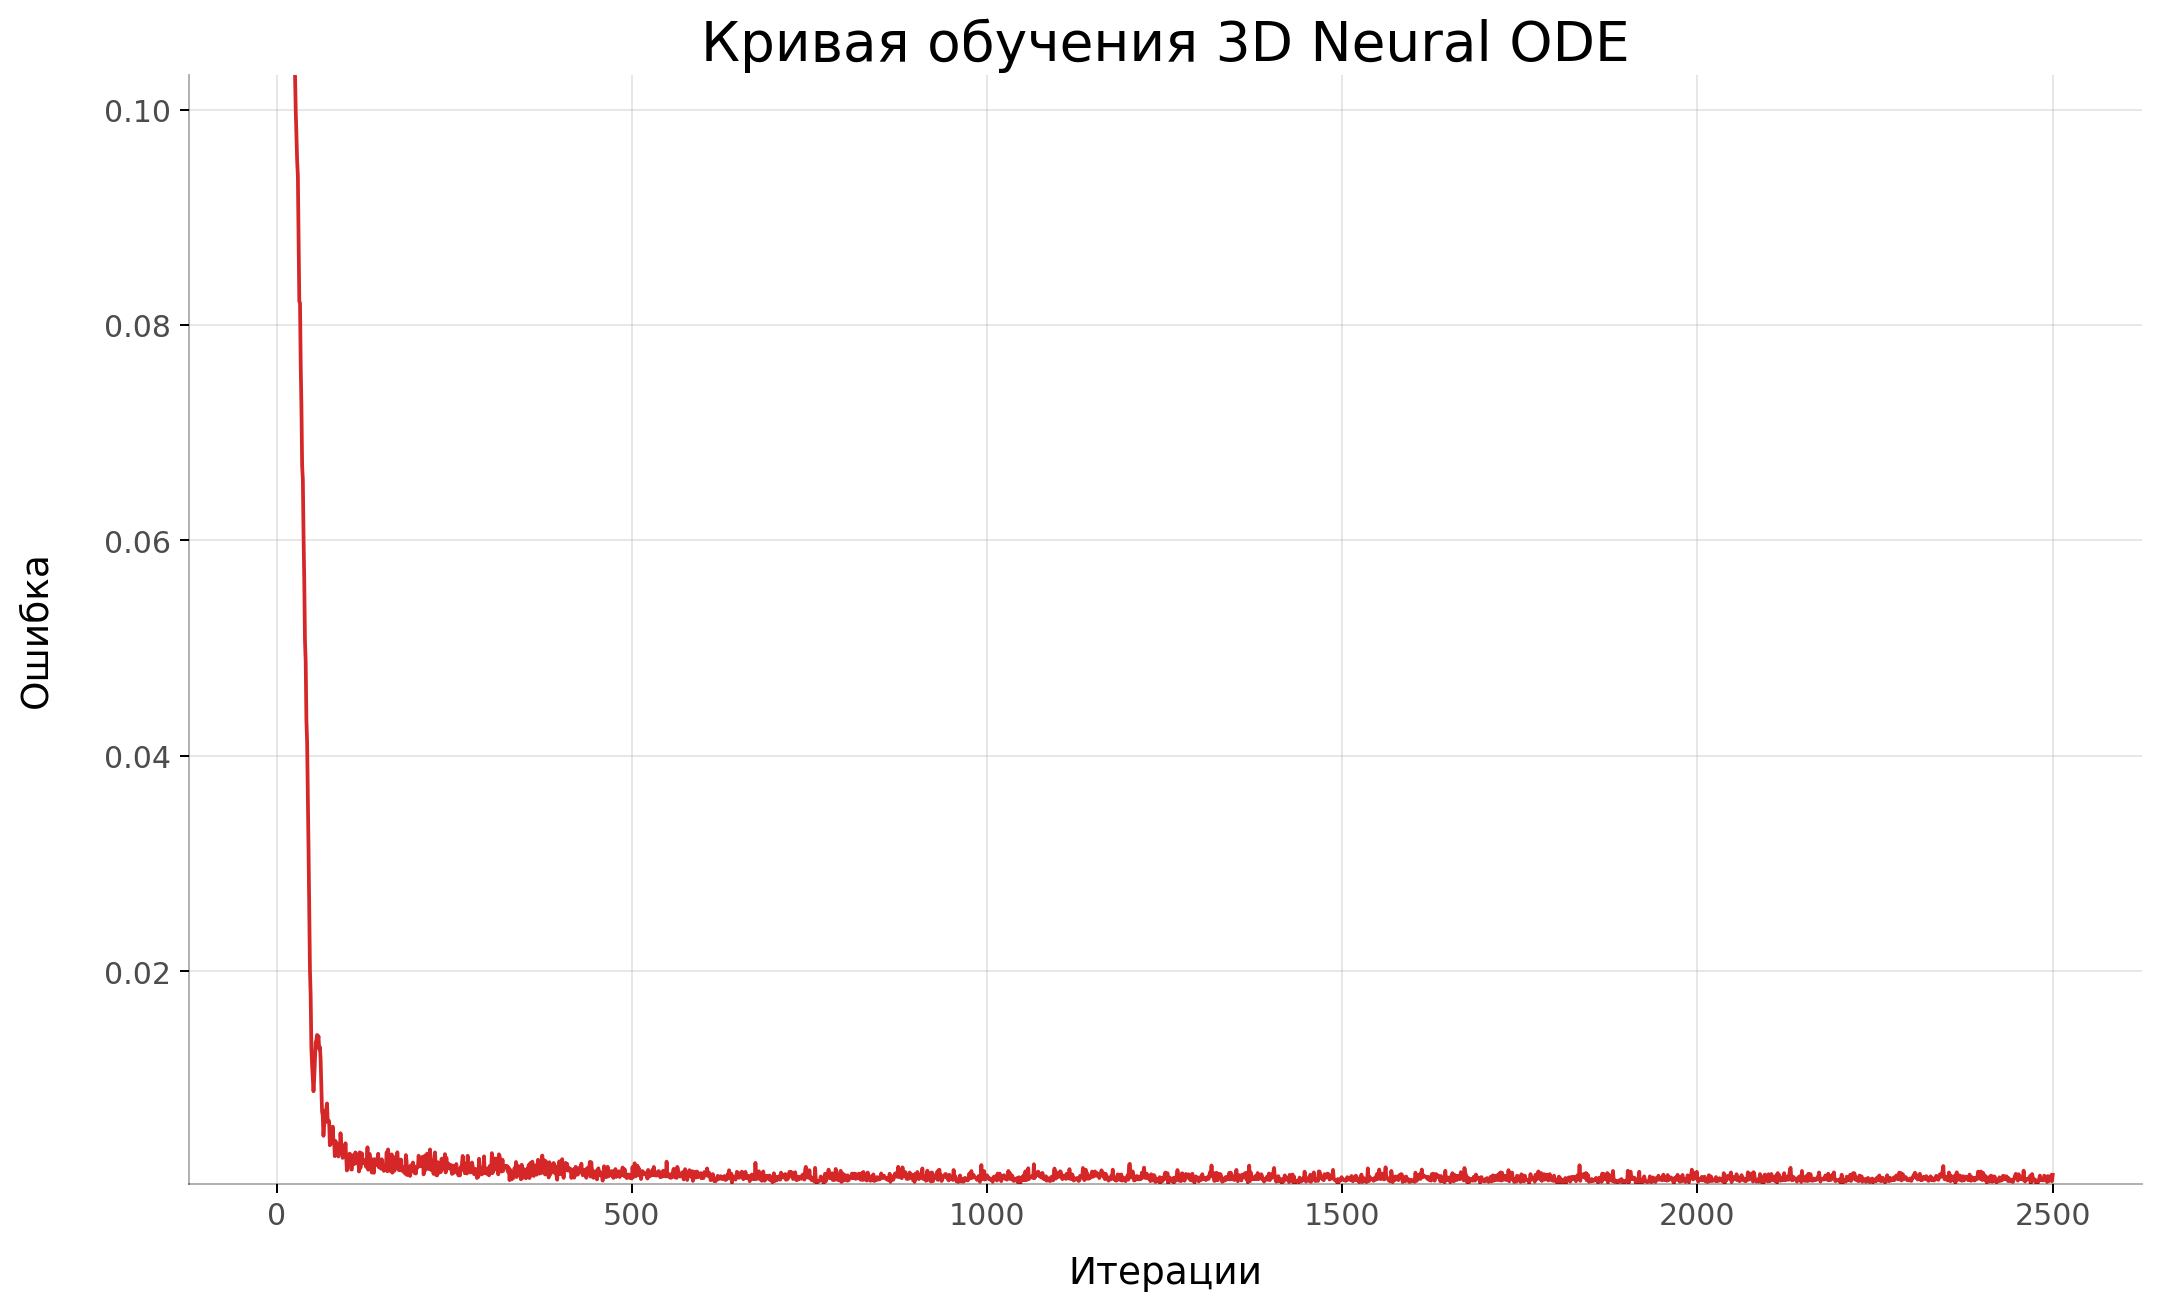

In [ ]:
plt.figure(figsize=(14, 8), dpi=180)
plt.plot(loss_arr[0, :], loss_arr[1, :], color='tab:red')

plt.xticks(rotation=0, fontsize=12, horizontalalignment='center', alpha=.7)
plt.yticks(fontsize=12, alpha=.7)
plt.ylim(
    ymin=loss_arr[1, :].min(),
    ymax=np.quantile(loss_arr[1, :], 0.99)
)
plt.xlabel("Итерации", fontsize=15, labelpad=10)
plt.ylabel("Ошибка", fontsize=15, labelpad=20)
plt.title("Кривая обучения 3D Neural ODE", fontsize=22)
plt.grid(axis='both', alpha=.3)

plt.gca().spines["top"].set_alpha(0.0)
plt.gca().spines["bottom"].set_alpha(0.3)
plt.gca().spines["right"].set_alpha(0.0)
plt.gca().spines["left"].set_alpha(0.3)

plt.savefig("nODE_3d_learning_curve.pdf", dpi=600)
plt.show()

In [ ]:
#ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ
func.load_state_dict(torch.load("best_model_3d.pth", map_location=device))
func.eval()


ODEFunc3D(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)

# 16. ТЕСТ НА НОВОМ НАЧАЛЬНОМ УСЛОВИИ


Test Loss on new initial condition: 0.567879


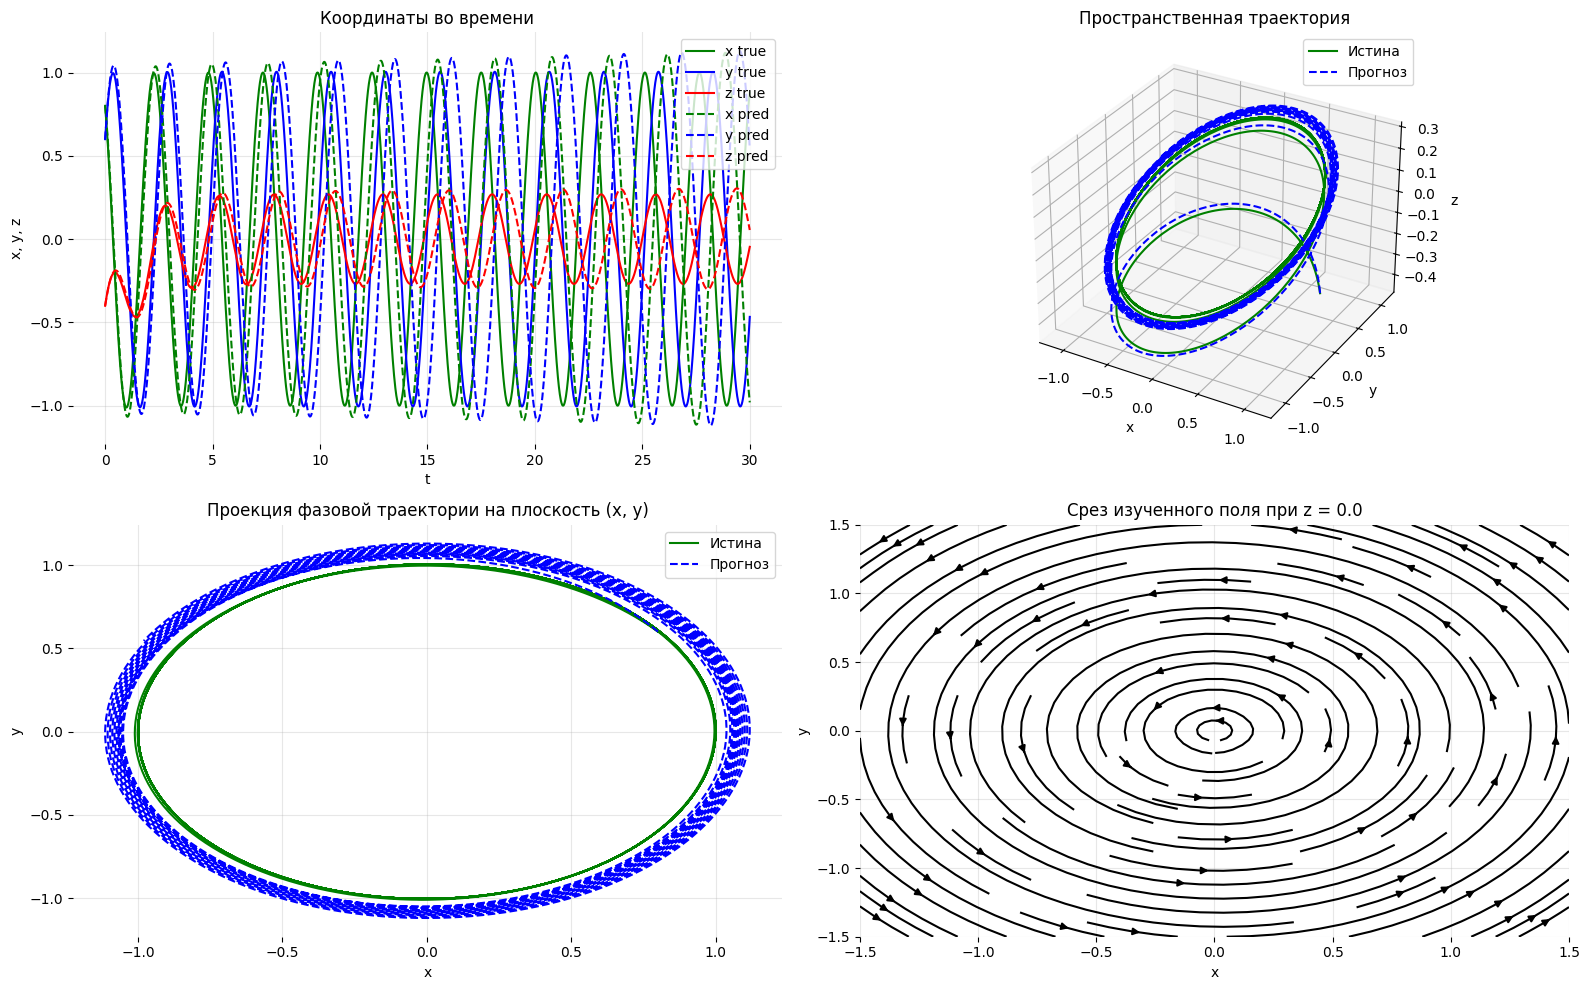

In [ ]:
test_y0 = torch.tensor([[0.8, 0.6, -0.4]], dtype=torch.float32).to(device)

with torch.no_grad():
    true_test_y = odeint(SpatialLambda(), test_y0, t, method='dopri5')
    pred_test_y = odeint(func, test_y0, t, method='dopri5')

test_loss = torch.mean(torch.abs(pred_test_y - true_test_y)).item()
print(f"Test Loss on new initial condition: {test_loss:.6f}")

with torch.no_grad():
    visualize(true_test_y, pred_test_y, func, 9999)